# BertTopic Comparison

In [ ]:
# ! pip install bertopic sentence-transformers umap-learn hdbscan

Learning References:
- https://maartengr.github.io/BERTopic/index.html

- Author: Brittany An
- Purpose: Use BERTopic to compare topics in pre-AI vs post-AI era news coverage of technical failrue events
- AI Usage: Used Claude to learn BertTopic concepts and packages usage, together with understanding/implementing chunking methods, also helped with refining docstrings/adding comments. This has more AI usage due to unfamiliarity with this topic. Thus included detailed comments in this notebook for learning purposes

In [14]:
import bertopic
import sentence_transformers
import umap
import hdbscan
print("All good!")

All good!


## data loading and chunking

In [16]:
import pandas as pd

base_path = "/Users/brittanyan/Desktop/final-project-error-502/data"
df = pd.read_csv(f"{base_path}/merged_relevant_articles.csv")

print(f"total rows: {len(df)}")
print(df['era'].value_counts())

total rows: 322
era
pre_ai     161
post_ai    161
Name: count, dtype: int64


In [22]:
def chunk_text(text, chunk_size=200, overlap=50):
    """
    Split a long article into shorter passages.
    
    chunk_size=200: ~200 words per chunk (sentence-transformers handles ~256 tokens max, 200 words fits safely)
    overlap=50:     50-word overlap between adjacent chunks (prevents key sentences from being cut in half)
    """
    # Split text into a list of words
    words = text.split()
    
    # Short articles don't need splitting — return as-is
    if len(words) <= chunk_size:
        return [text]
    
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size            # Take 200 words from start
        chunk = ' '.join(words[start:end])  # Join words back into a string
        if len(chunk.split()) >= 30:        # Drop tail fragments under 30 words
            chunks.append(chunk)
        start += chunk_size - overlap       # Advance 150 steps (200-50), so 50 words overlap
    # Note: short articles (<= 200 words) are kept as-is regardless of length
    # The >= 30 filter only applies to tail fragments from long articles (200+ words)
    
    return chunks

In [24]:
chunk_records = [] # Empty list to collect info for all chunks (list of dicts)

for idx in range(len(df)):
    # Loop through each article (idx goes from 0 to 321)
    chunks = chunk_text(str(df.iloc[idx]['text_for_analysis']))
    # Get the text of article idx, split it into chunks
    # Returns a list, e.g. ["chunk0 text", "chunk1 text", "chunk2 text"]
    
    for ci, chunk in enumerate(chunks):
        # Loop through each chunk: ci = chunk number, chunk = text content
        chunk_records.append({
            'doc_id': idx,                   # Which article this chunk belongs to
            'chunk_id': ci,                  # Which chunk within that article
            'text': chunk,                   # The chunk text
            'era': df.iloc[idx]['era'],       # Inherit era label from article
            'event': df.iloc[idx]['event'],   # Inherit event label from article
        })

# Convert list of dicts to DataFrame: each row = one chunk
chunk_df = pd.DataFrame(chunk_records)
print(f"{len(df)} articles → {len(chunk_df)} chunks")
print(f"  pre_ai:  {(chunk_df['era']=='pre_ai').sum()} chunks")
print(f"  post_ai: {(chunk_df['era']=='post_ai').sum()} chunks")

322 articles → 2001 chunks
  pre_ai:  1076 chunks
  post_ai: 925 chunks


In [26]:
chunk_df

,doc_id,chunk_id,text,era,event
0,0,0,Several Amazon services – including its websit...,pre_ai,aws_2021
1,0,1,"sources, including user-submitted errors on it...",pre_ai,aws_2021
2,0,2,"companies globally, all Adele Verified Fan Pre...",pre_ai,aws_2021
3,1,0,TV personality Jessica Rowe has reinvented her...,pre_ai,facebook_2021
4,1,1,was swift. Australian of the year Grace Tame s...,pre_ai,facebook_2021
...,...,...,...,...,...
1996,317,0,The flight disruptions brought on by the globa...,post_ai,crowdstrike_2024
1997,318,0,Fears of a hard landing are rocking global sto...,post_ai,crowdstrike_2024
1998,319,0,The cybersecurity company said the airline sho...,post_ai,crowdstrike_2024
1999,320,0,The software company said in a letter that Del...,post_ai,crowdstrike_2024


## BERTopic Model Setup

In [28]:
from bertopic import BERTopic                            # Main model
from sentence_transformers import SentenceTransformer    # Step 1: Convert text into numerical vectors (embeddings)
from umap import UMAP                                    # Step 2: Reduce embedding dimensions (384 → 5)
from hdbscan import HDBSCAN                              # Step 3: Cluster embeddings to discover topics
from sklearn.feature_extraction.text import CountVectorizer  # Step 4: Control how keywords are extracted per topic (c-TF-IDF)

In [31]:
# Embedding model: converts text into 384-dimensional vectors
# "all-MiniLM-L6-v2" is a lightweight English model, fast and effective
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

In [33]:
# UMAP: reduce embedding dimensions from 384 to 5
# n_neighbors=15:  how many nearby points to consider (larger = more global structure)
# n_components=5:  target dimensions (BERTopic recommended)
# min_dist=0.0:    allow points to be very close (helps clustering)
# metric='cosine': use cosine similarity (standard for text)
# random_state=42: fix random seed for reproducible results
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

In [51]:
# HDBSCAN: automatically cluster chunks into topics
# min_cluster_size=10:  at least 10 chunks to form a topic (larger = fewer broader topics)
# min_samples=3:        core point needs at least 3 neighbors (controls noise sensitivity)
# prediction_data=True: keep probability info (needed for averaging later)
hdbscan_model = HDBSCAN(
    min_cluster_size=25,    # Changed from 10 to 25: more chunks to form a topic(fewer, cleaner topics)
    min_samples=3,
    metric='euclidean',
    prediction_data=True
)

In [53]:
# CountVectorizer: controls how c-TF-IDF extracts keywords per topic
# ngram_range=(1,2): extract single words AND two-word phrases (e.g. "cloud" and "cloud computing")
# stop_words='english': remove meaningless words like "the", "is", "at"
# min_df=3: a word must appear in at least 3 chunks to be kept
vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)

## Run BERTopic (Pre-AI vs Post-AI)

### Pre_AI

In [55]:
# Pre-AI
pre_texts = chunk_df[chunk_df['era'] == 'pre_ai']['text'].tolist()
print(f"Pre-AI: {len(pre_texts)} chunks")

# Step 1: Compute embeddings 
print("Computing embeddings")
pre_embeddings = embedding_model.encode(pre_texts, show_progress_bar=True, batch_size=32)
print(f"Embeddings shape: {pre_embeddings.shape}")

Pre-AI: 1076 chunks
Computing embeddings


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Embeddings shape: (1076, 384)


In [57]:
# Create BERTopic model with all configured components
# This assembles the full pipeline: embedding → UMAP → HDBSCAN → c-TF-IDF
pre_model = BERTopic(
    embedding_model=embedding_model,   # Text → vectors (already computed)
    umap_model=umap_model,             # 384 dims → 5 dims
    hdbscan_model=hdbscan_model,       # Cluster chunks into topics
    vectorizer_model=vectorizer,       # Extract keywords per topic
    top_n_words=10,                    # Show top 10 keywords per topic
    verbose=True                       # Print progress
)

# fit_transform: train the model and assign a topic to each chunk
# Internally runs: UMAP dimensionality reduction → HDBSCAN clustering → c-TF-IDF keyword extraction
# Returns:
#   pre_topics: list of topic IDs for each chunk (e.g. [0, 0, 3, -1, 2, ...], -1 = noise/outlier)
#   pre_probs:  probability of each chunk belonging to its assigned topic
print("Fitting BERTopic on Pre-AI chunks...")
pre_topics, pre_probs = pre_model.fit_transform(pre_texts, pre_embeddings)

2026-02-25 16:01:20,578 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic on Pre-AI chunks...


2026-02-25 16:01:21,788 - BERTopic - Dimensionality - Completed ✓
2026-02-25 16:01:21,789 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-25 16:01:21,798 - BERTopic - Cluster - Completed ✓
2026-02-25 16:01:21,799 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 16:01:21,884 - BERTopic - Representation - Completed ✓


In [59]:
# View discovered topics for Pre-AI era
# get_topic_info() returns a table: Topic ID, Count (how many chunks), top keywords
pre_topic_info = pre_model.get_topic_info()
print(f"Found {len(pre_topic_info[pre_topic_info['Topic'] != -1])} topics")
print(f"Noise chunks (Topic -1): {pre_topic_info[pre_topic_info['Topic']==-1]['Count'].values[0]}")
print()
pre_topic_info

Found 11 topics
Noise chunks (Topic -1): 149



,Topic,Count,Name,Representation,Representative_Docs
0,-1,149,-1_women_says_people_like,"[women, says, people, like, men, new, health, ...",[almost always looking for someone younger tha...
1,0,361,0_facebook_haugen_company_said,"[facebook, haugen, company, said, content, soc...",[that have been sued by government agencies. U...
2,1,117,1_climate_change_crisis_global,"[climate, change, crisis, global, climate cris...",[in their hundreds to join climate change marc...
3,2,90,2_like_think_just_people,"[like, think, just, people, season, don, famil...",[she said. “I still feel like I’m 15 years old...
4,3,78,3_australia_covid_new_australian,"[australia, covid, new, australian, sign, nsw,...",[Ashes tour is not a done deal as it pushes to...
5,4,60,4_services_outage_fastly_amazon,"[services, outage, fastly, amazon, google, lap...","[sources, including user-submitted errors on i..."
6,5,57,5_year_perrottet_said_pandemic,"[year, perrottet, said, pandemic, uk, governme...",[fall on the year to date. The direct impact c...
7,6,45,6_trump_clegg_twitter_president,"[trump, clegg, twitter, president, facebook, m...","[be honest with you,” Trump said in a 2017 int..."
8,7,33,7_art_like_mike_music,"[art, like, mike, music, korea, south, hong, s...",[time. “I always need to show a good appearanc...
9,8,29,8_metaverse_reality_virtual_facebook,"[metaverse, reality, virtual, facebook, compan...","[reality, where a digital layer is placed on t..."


### Post_AI

In [63]:
# --- Post-AI era ---
post_texts = chunk_df[chunk_df['era'] == 'post_ai']['text'].tolist()
print(f"Post-AI: {len(post_texts)} chunks")

# Compute embeddings
print("Computing embeddings...")
post_embeddings = embedding_model.encode(post_texts, show_progress_bar=True, batch_size=32)
print(f"Embeddings shape: {post_embeddings.shape}")

Post-AI: 925 chunks
Computing embeddings...


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Embeddings shape: (925, 384)


In [65]:
# Create and train BERTopic model for Post-AI era
post_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    top_n_words=10,
    verbose=True
)

print("Fitting BERTopic on Post-AI chunks...")
post_topics, post_probs = post_model.fit_transform(post_texts, post_embeddings)

2026-02-25 16:04:20,047 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic on Post-AI chunks...


2026-02-25 16:04:21,045 - BERTopic - Dimensionality - Completed ✓
2026-02-25 16:04:21,045 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-25 16:04:21,053 - BERTopic - Cluster - Completed ✓
2026-02-25 16:04:21,054 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 16:04:21,130 - BERTopic - Representation - Completed ✓


In [67]:
post_topic_info = post_model.get_topic_info()
print(f"Found {len(post_topic_info[post_topic_info['Topic'] != -1])} topics")
print(f"Noise chunks (Topic -1): {post_topic_info[post_topic_info['Topic']==-1]['Count'].values[0]}")
print()
post_topic_info

Found 10 topics
Noise chunks (Topic -1): 79



,Topic,Count,Name,Representation,Representative_Docs
0,-1,79,-1_water_nuclear_energy_says,"[water, nuclear, energy, says, wedding, love, ...",[Amazon strategised about keeping the public i...
1,0,196,0_said_outage_crowdstrike_systems,"[said, outage, crowdstrike, systems, friday, u...","[airline, which said on its website: “Potentia..."
2,1,141,1_ai_amazon_services_cloud,"[ai, amazon, services, cloud, company, interne...",[out across the modern economy – from banking ...
3,2,91,2_film_read_said_review,"[film, read, said, review, like, movie, life, ...",[Oppenheimer’s end-of-the-world singalong dram...
4,3,90,3_trump_biden_musk_president,"[trump, biden, musk, president, guy, said, stu...",[college town in the US. A few days of backlas...
5,4,87,4_said_family_india_told,"[said, family, india, told, men, year, husband...","[volunteered at the temple. Raxa Modha, her da..."
6,5,69,5_university_professor_climate_people,"[university, professor, climate, people, londo...",[under threat. We urge the Labour government t...
7,6,54,6_cup_world_football_england,"[cup, world, football, england, fans, game, le...","[European Super League, which was bound up in ..."
8,7,48,7_stone_black_beauty_like,"[stone, black, beauty, like, song, women, natu...","[was Stone finding peace in self-acceptance, a..."
9,8,44,8_israel_israeli_microsoft_said,"[israel, israeli, microsoft, said, gaza, compa...",[The company’s investigation did nothing to as...


### notes


Note: due to insufficient data cleaning, topics are a bit noisy right now

## Aggregate Chunks to Document Level

In [72]:
# Assign topic to each chunk in Pre-AI
pre_chunk_df = chunk_df[chunk_df['era'] == 'pre_ai'].copy()
pre_chunk_df['topic'] = pre_topics

# For each article: count which topic appears most among its chunks (ignoring noise -1)
# This is the "averaging" step — aggregate chunk-level topics back to document level
pre_doc_topics = pre_chunk_df.groupby('doc_id')['topic'].apply(
    lambda x: x[x != -1].value_counts().index[0] if len(x[x != -1]) > 0 else -1
)

print("Pre-AI: document-level topic distribution")
print(pre_doc_topics.value_counts().sort_index())

Pre-AI: document-level topic distribution
topic
-1     10
 0     74
 1     10
 2     13
 3     14
 4     13
 5      9
 6      5
 7      4
 8      5
 9      2
 10     2
Name: count, dtype: int64


In [74]:
# Assign topic to each chunk in Post-AI
post_chunk_df = chunk_df[chunk_df['era'] == 'post_ai'].copy()
post_chunk_df['topic'] = post_topics

# Aggregate chunk-level topics back to document level
post_doc_topics = post_chunk_df.groupby('doc_id')['topic'].apply(
    lambda x: x[x != -1].value_counts().index[0] if len(x[x != -1]) > 0 else -1
)

print("Post-AI: document-level topic distribution")
print(post_doc_topics.value_counts().sort_index())

Post-AI: document-level topic distribution
topic
-1     9
 0    58
 1    32
 2    10
 3    11
 4    12
 5     8
 6     8
 7     4
 8     6
 9     3
Name: count, dtype: int64


# Visualization

https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html#visualize-topics

## preAI

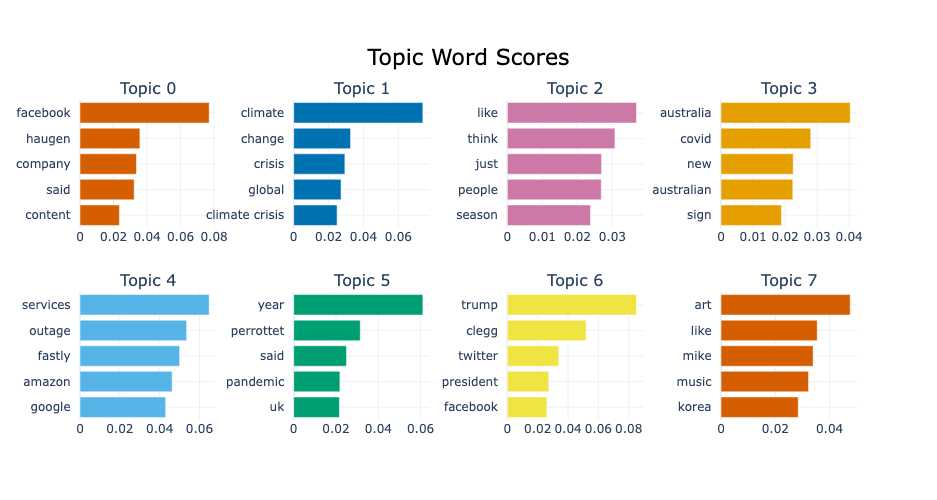

In [78]:
fig = pre_model.visualize_barchart(top_n_topics=8)
fig.show()

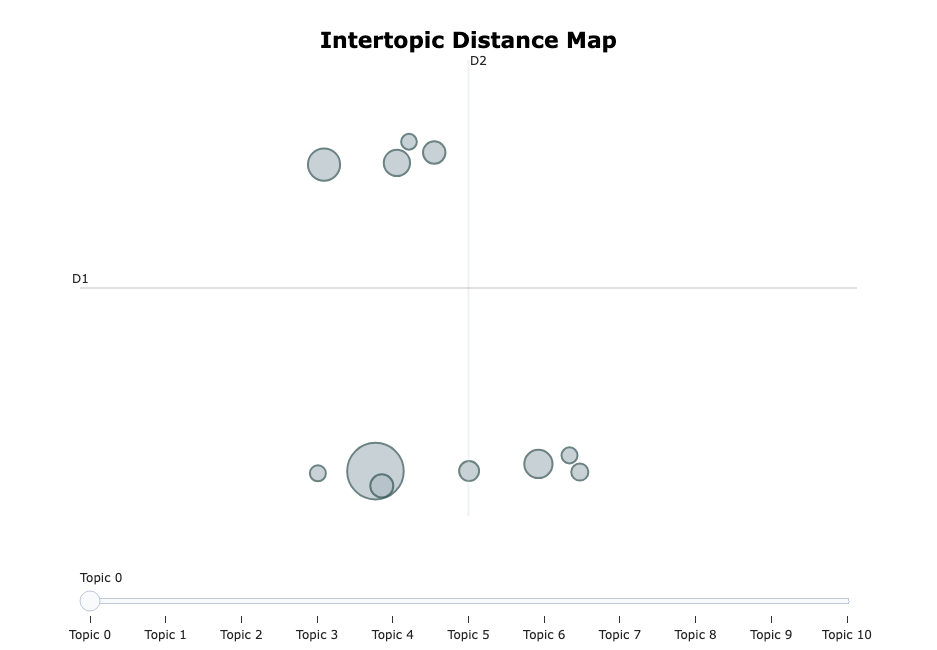

In [81]:
# Intertopic distance map: shows how topics relate to each other in 2D space
fig = pre_model.visualize_topics()
fig.show()

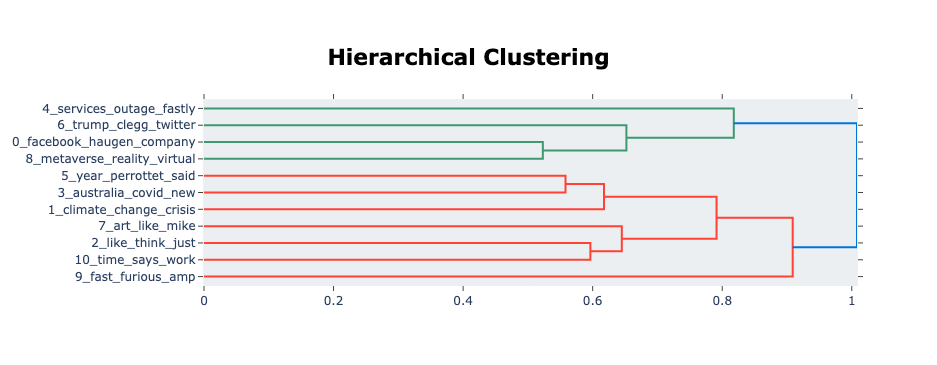

In [83]:
# Hierarchy: tree structure showing which topics are similar
fig = pre_model.visualize_hierarchy()
fig.show()

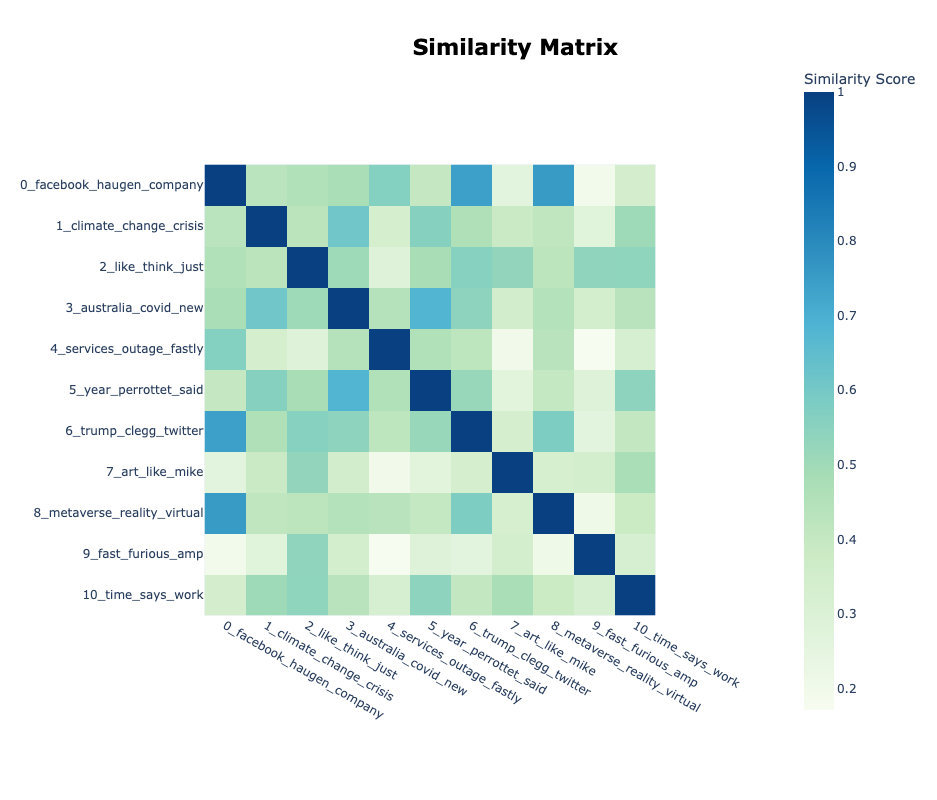

In [85]:
# Heatmap: similarity between topics
fig = pre_model.visualize_heatmap()
fig.show()


## postAI

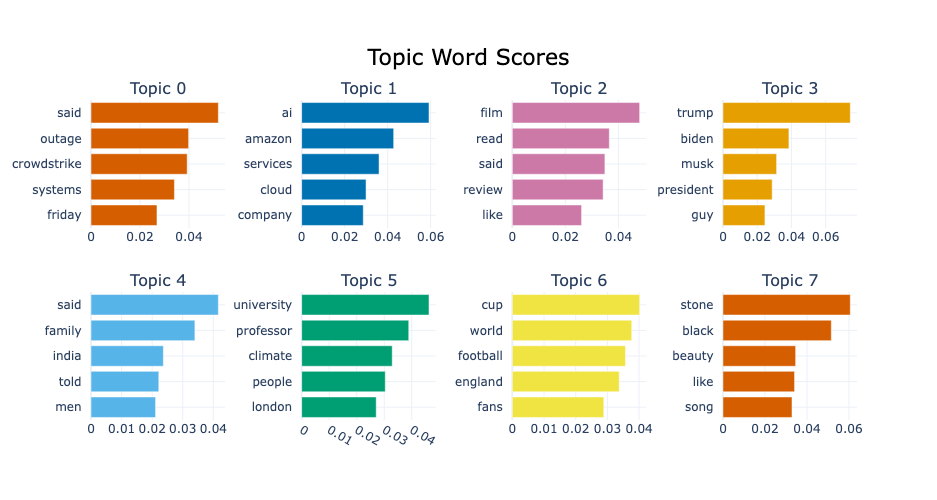

In [89]:
fig = post_model.visualize_barchart(top_n_topics=8)
fig.show()

## compare

### chunk level

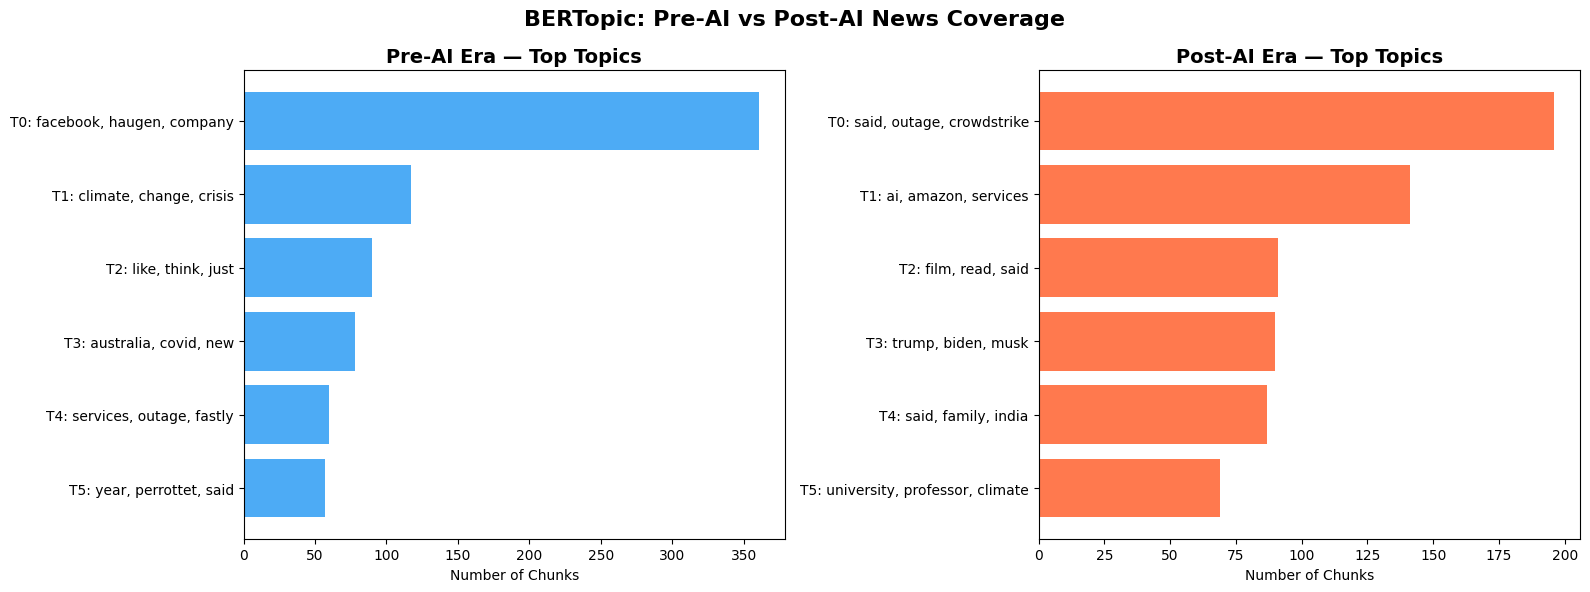

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pre-AI ---
ax = axes[0]
pre_info = pre_model.get_topic_info()
pre_info = pre_info[pre_info['Topic'] != -1].head(6)  # Top 6 topics, exclude noise

labels = []
counts = []
for _, row in pre_info.iterrows():
    words = [w for w, _ in pre_model.get_topic(row['Topic'])][:3]
    labels.append(f"T{row['Topic']}: {', '.join(words)}")
    counts.append(row['Count'])

ax.barh(range(len(labels)), counts, color='#2196F3', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Chunks')
ax.set_title('Pre-AI Era — Top Topics', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# --- Post-AI ---
ax = axes[1]
post_info = post_model.get_topic_info()
post_info = post_info[post_info['Topic'] != -1].head(6)

labels = []
counts = []
for _, row in post_info.iterrows():
    words = [w for w, _ in post_model.get_topic(row['Topic'])][:3]
    labels.append(f"T{row['Topic']}: {', '.join(words)}")
    counts.append(row['Count'])

ax.barh(range(len(labels)), counts, color='#FF5722', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Chunks')
ax.set_title('Post-AI Era — Top Topics', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.suptitle('BERTopic: Pre-AI vs Post-AI News Coverage', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_path}/analysis&visualization/bertopic_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### document level

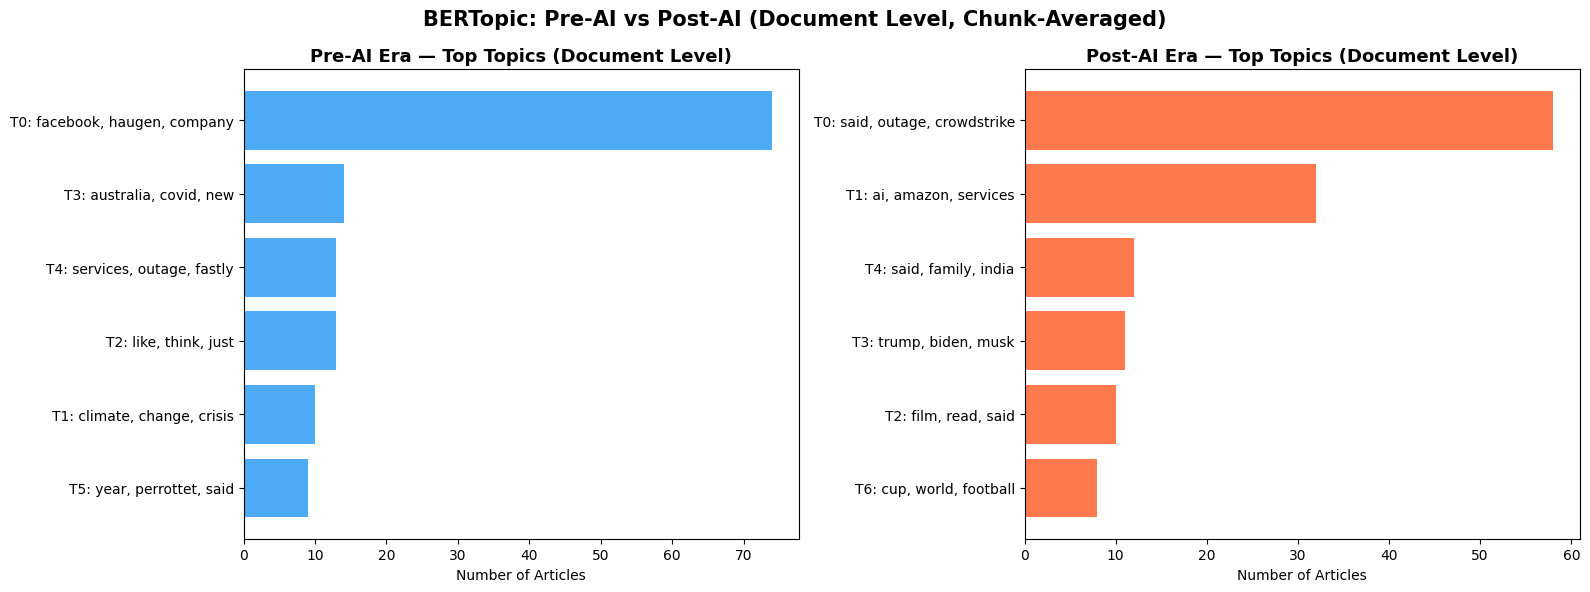

In [94]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pre-AI (document level) ---
ax = axes[0]
pre_counts = pre_doc_topics.value_counts().sort_values(ascending=False)
pre_counts = pre_counts[pre_counts.index != -1].head(6)  # Exclude noise, top 6

labels = []
for tid in pre_counts.index:
    words = [w for w, _ in pre_model.get_topic(tid)][:3]
    labels.append(f"T{tid}: {', '.join(words)}")

ax.barh(range(len(labels)), pre_counts.values, color='#2196F3', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Articles')
ax.set_title('Pre-AI Era — Top Topics (Document Level)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# --- Post-AI (document level) ---
ax = axes[1]
post_counts = post_doc_topics.value_counts().sort_values(ascending=False)
post_counts = post_counts[post_counts.index != -1].head(6)

labels = []
for tid in post_counts.index:
    words = [w for w, _ in post_model.get_topic(tid)][:3]
    labels.append(f"T{tid}: {', '.join(words)}")

ax.barh(range(len(labels)), post_counts.values, color='#FF5722', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Articles')
ax.set_title('Post-AI Era — Top Topics (Document Level)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

plt.suptitle('BERTopic: Pre-AI vs Post-AI (Document Level, Chunk-Averaged)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_path}/analysis&visualization/bertopic_doc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Key Findings from BERTopic Analysis (Document Level, Chunk-Averaged)

### Pre-AI Era:
- The dominant topic is Facebook/Haugen whistleblower scandal (74 out of 161 articles), 
  suggesting that pre-AI outage coverage was heavily driven by a single corporate scandal narrative.
- The actual technical outage topic (T4: services, outage, fastly) accounts for only 14 articles, 
  indicating that outage events themselves received relatively limited focused coverage.
- Other topics are mostly unrelated noise (australia/covid, climate), reflecting the broader news 
  context surrounding outage event periods.

### Post-AI Era:
- CrowdStrike outage (T0) dominates with 58 articles, showing that post-AI outage coverage 
  is more directly focused on the outage event itself.
- A new AI/cloud topic (T1: ai, amazon, services) emerges with 32 articles — this topic 
  did not exist in the pre-AI era, suggesting that AI and cloud infrastructure have become 
  central to how outages are framed in news coverage.
- Political figures (T3: trump, biden, musk) appear as a distinct topic, indicating that 
  outage reporting in the post-AI era has become more politicized.

### Pre-AI vs Post-AI Comparison:
- Pre-AI coverage was dominated by corporate scandal (Facebook/Haugen); 
  Post-AI coverage is more focused on technical outage events (CrowdStrike).
- The emergence of "AI" as a top keyword in Post-AI era is a notable shift — 
  outage events are increasingly discussed in the context of AI infrastructure and dependency.
- Both eras contain significant noise topics due to unrelated articles in the dataset; 
  further data cleaning could improve topic clarity.